### Read and Pre-Process

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

keep_columns = ['LA_2023', 'LondInOut', 'Gend3', 'Disab3', 'Age5', 'Relig7', 'Orient4', 'Educ6', 'Eth7', 'DVBMI', 'VolAny', 'NSSEC5', 'DURATION_SPORTCOUNT_A01', 'MEMS7_IN_SPORTCOUNT_A01', 'MEMS7_OUT_SPORTCOUNT_A01', 'wt_final']
df = pd.read_spss('active_lives_survey_nov_22-23_data_year_8_shared_20250103.sav', usecols = keep_columns)

# Numeric Cols
df['DURATION_SPORTCOUNT_A01'] = pd.to_numeric(df['DURATION_SPORTCOUNT_A01'])
df['MEMS7_IN_SPORTCOUNT_A01'] = pd.to_numeric(df['MEMS7_IN_SPORTCOUNT_A01'])
df['MEMS7_OUT_SPORTCOUNT_A01'] = pd.to_numeric(df['MEMS7_OUT_SPORTCOUNT_A01'])
df['wt_final'] = pd.to_numeric(df['wt_final'])
df['DVBMI'] = pd.to_numeric(df['DVBMI'])

# Filters
df = df[df['LondInOut'].notna()]
df = df[df['DURATION_SPORTCOUNT_A01'] >= 150]

# Handle LA codes
df['LA_2023'] = df['LA_2023'].astype(str)
df['LA_Code'] = df['LA_2023'].str.split(' ').str[0]
df['LA_Name'] = df['LA_2023'].str.split(' ').str[1]
df.drop(columns = ['LA_2023'], inplace = True)

# Count Missingess
df['Missingness'] = df.isnull().sum(axis = 1)
df.to_csv('active_lives_london.csv', index = False)
print(f'Shape: {df.shape}')

Shape: (11498, 18)


### Examine Impact of Including Demographic on Cohort Sizes

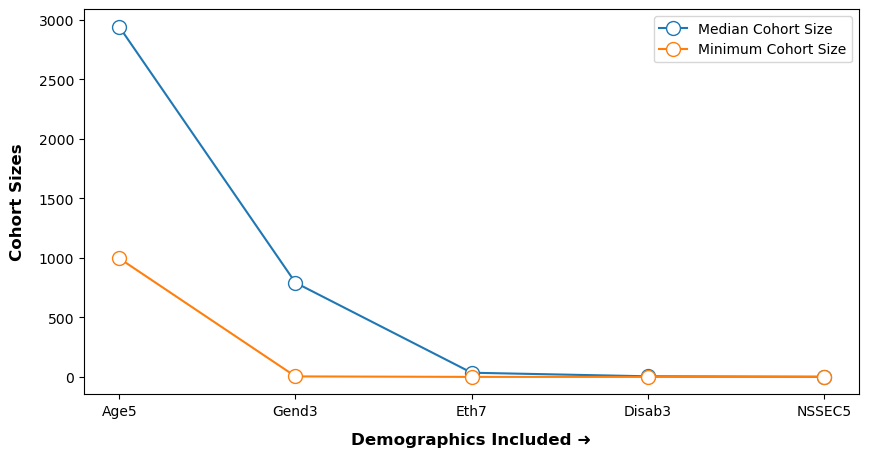

In [2]:
keep_columns = ['Age5', 'Gend3', 'Eth7', 'Disab3', 'NSSEC5']
minimums = []
medians = []
attributes = []

for i in range(len(keep_columns)):
    demographics = keep_columns[:i + 1]
    cohorts = df.groupby(demographics, observed = False)
    minimums.append(cohorts.size().min())
    medians.append(cohorts.size().median())
    attributes.append(df[keep_columns[i]].nunique())

fig, ax = plt.subplots(figsize = (10, 5))
fig.patch.set_facecolor('white')
ax.plot(keep_columns, medians, marker = 'o', markerfacecolor = 'white', markersize = 10, label = 'Median Cohort Size')
ax.plot(keep_columns, minimums, marker = 'o', markerfacecolor = 'white', markersize = 10, label = 'Minimum Cohort Size')
ax.legend(loc = 'upper right')
plt.xlabel('Demographics Included ➜', fontsize = 12, labelpad = 10, fontweight = "bold")
plt.ylabel('Cohort Sizes', fontsize = 12, labelpad = 10, fontweight = "bold")
plt.show()